In [ ]:
#Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [ ]:
%pip install pandas

In [11]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow



SyntaxError: invalid syntax (2890737779.py, line 1)

In [ ]:
#Load Dataset

df = pd.read_csv("C:\\Users\\USER\\Desktop\\nikhil project\\weather_clean_18000.csv")
df.head()


,date,humidity,wind_speed,pressure,temperature
0,2000-01-01,58.727006,4.874144,1022.497771,21.084193
1,2000-01-02,87.535715,3.414511,1023.506408,12.906167
2,2000-01-03,76.599697,3.831455,995.132304,24.699226
3,2000-01-04,69.932924,5.300349,1004.512251,18.934355
4,2000-01-05,47.800932,6.257836,1020.121341,23.608197


In [ ]:
#Dataset Info

print("Shape:", df.shape)
df.info()


Shape: (18000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         18000 non-null  object 
 1   humidity     18000 non-null  float64
 2   wind_speed   18000 non-null  float64
 3   pressure     18000 non-null  float64
 4   temperature  18000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 703.2+ KB


In [ ]:
#Date Processing

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)


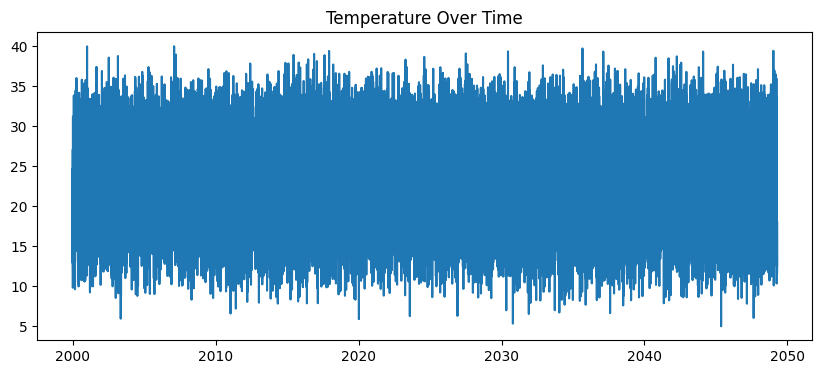

In [ ]:
#Temperature Over Time

plt.figure(figsize=(10,4))
plt.plot(df['temperature'])
plt.title("Temperature Over Time")
plt.show()


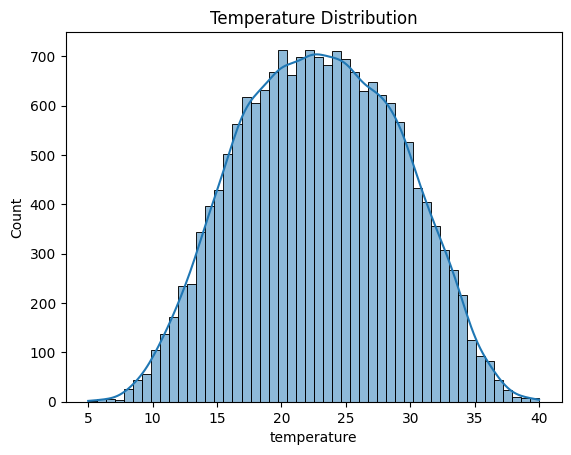

In [ ]:
#Temperature Distribution

sns.histplot(df['temperature'], kde=True)
plt.title("Temperature Distribution")
plt.show()


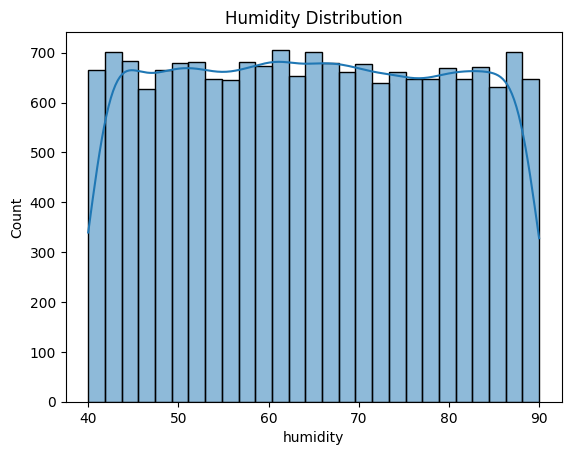

In [ ]:
#Humidity Distribution

sns.histplot(df['humidity'], kde=True)
plt.title("Humidity Distribution")
plt.show()


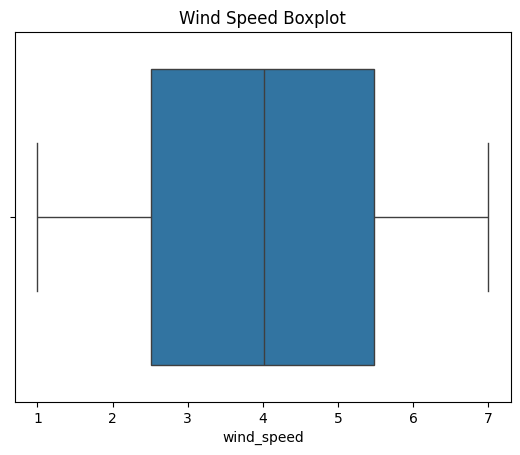

In [ ]:
#Wind Speed Boxplot

sns.boxplot(x=df['wind_speed'])
plt.title("Wind Speed Boxplot")
plt.show()


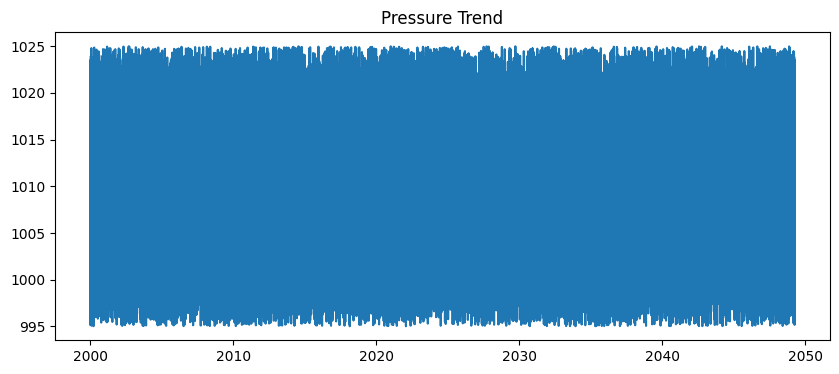

In [ ]:
#Pressure Trend

plt.figure(figsize=(10,4))
plt.plot(df['pressure'])
plt.title("Pressure Trend")
plt.show()


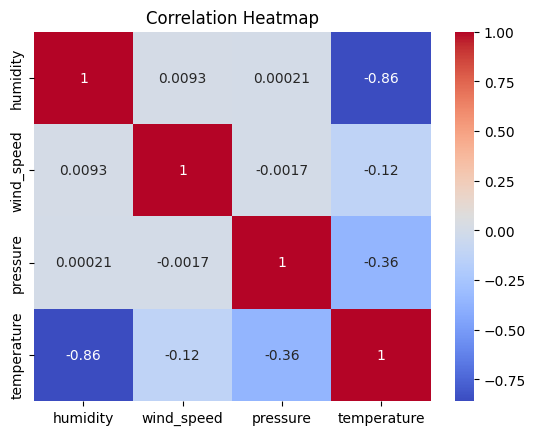

In [ ]:
#Correlation Heatmap

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


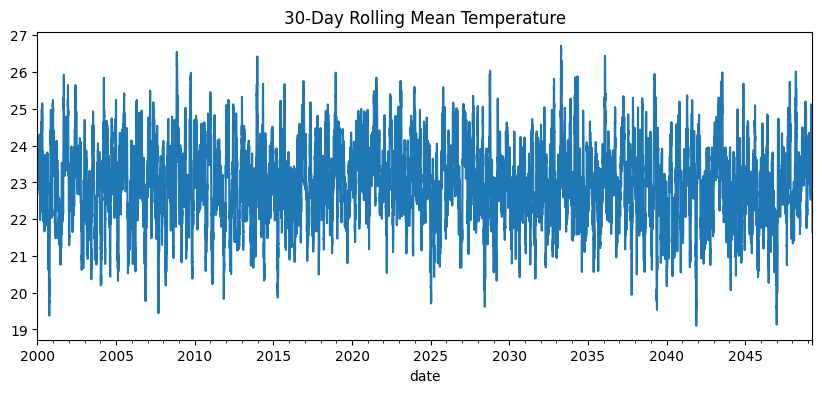

In [ ]:
#Rolling Mean

df['temperature'].rolling(30).mean().plot(figsize=(10,4))
plt.title("30-Day Rolling Mean Temperature")
plt.show()


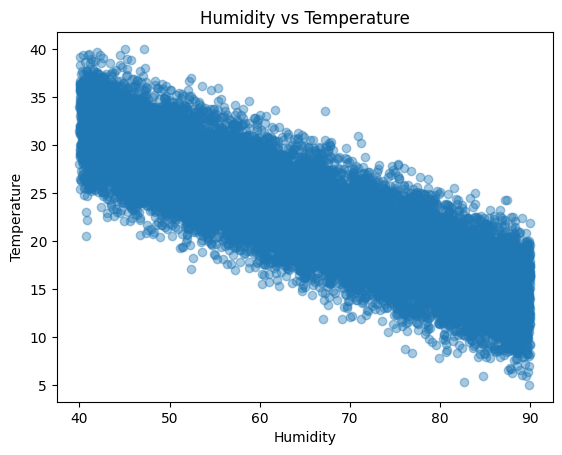

In [ ]:
#Humidity vs Temperature

plt.scatter(df['humidity'], df['temperature'], alpha=0.4)
plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Humidity vs Temperature")
plt.show()


In [ ]:
#Features & Target

# Recreate features and target
X = df[['humidity', 'wind_speed', 'pressure']]
y = df['temperature']


In [ ]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [ ]:
#MACHINE LEARNING MODELS

In [ ]:
#RANDOM FOREST

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy (R² %):", r2_score(y_test, y_pred_rf)*100)


Random Forest Accuracy (R² %): 86.9605803239719


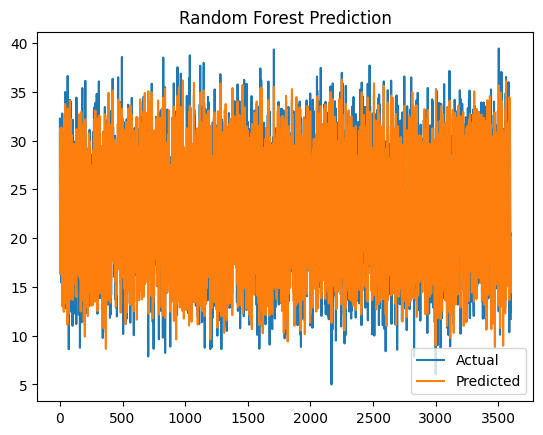

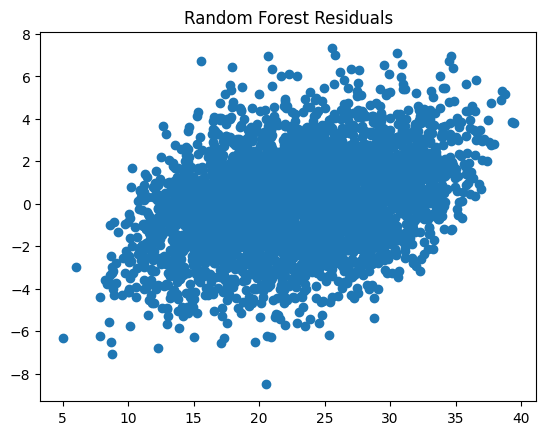

In [ ]:
#Graphs

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_rf, label="Predicted")
plt.legend()
plt.title("Random Forest Prediction")
plt.show()

plt.scatter(y_test, y_test - y_pred_rf)
plt.title("Random Forest Residuals")
plt.show()


In [ ]:
#GRADIENT BOOSTING

gbr = GradientBoostingRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

print("Gradient Boosting Accuracy (R² %):", r2_score(y_test, y_pred_gbr)*100)


Gradient Boosting Accuracy (R² %): 88.16337614093962


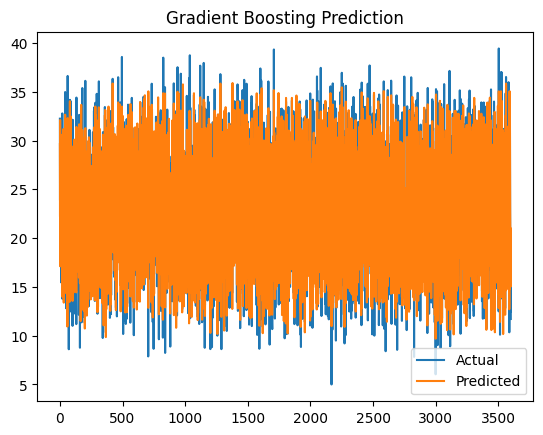

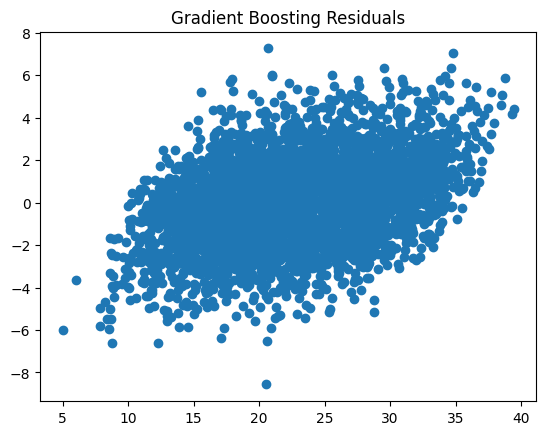

In [ ]:
#Graphs

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_gbr, label="Predicted")
plt.legend()
plt.title("Gradient Boosting Prediction")
plt.show()

plt.scatter(y_test, y_test - y_pred_gbr)
plt.title("Gradient Boosting Residuals")
plt.show()


In [ ]:
#SVR (WITH SCALING)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

svr = SVR(kernel='rbf', C=120, gamma=0.08)
svr.fit(X_train_s, y_train)

y_pred_svr = svr.predict(X_test_s)

print("SVR Accuracy (R² %):", r2_score(y_test, y_pred_svr)*100)


SVR Accuracy (R² %): 88.3390594635888


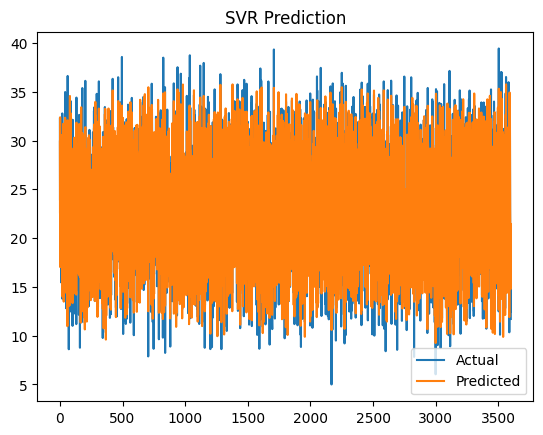

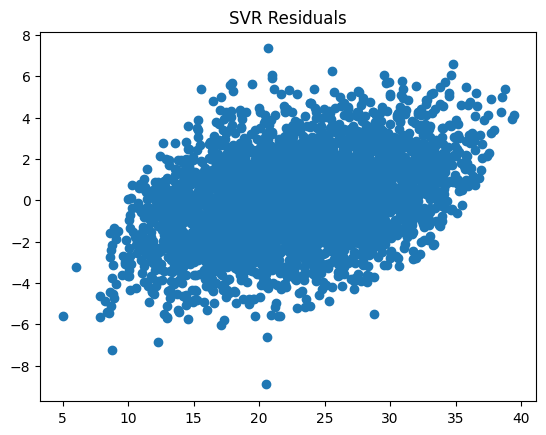

In [ ]:
#Graphs

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_svr, label="Predicted")
plt.legend()
plt.title("SVR Prediction")
plt.show()

plt.scatter(y_test, y_test - y_pred_svr)
plt.title("SVR Residuals")
plt.show()


In [ ]:
#DEEP LEARNING MODEL - LSTM

In [ ]:
#LSTM

scaler_dl = MinMaxScaler()
scaled = scaler_dl.fit_transform(
    df[['humidity','wind_speed','pressure','temperature']]
)


In [ ]:
#Create Sequences

def create_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len, :-1])
        y.append(data[i+seq_len, -1])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(scaled)


In [ ]:
#Train-Test Split (DL)

split = int(0.8 * len(X_lstm))

X_train, X_test = X_lstm[:split], X_lstm[split:]
y_train, y_test = y_lstm[:split], y_lstm[split:]


In [ ]:
#LSTM MODEL

In [ ]:
#Build Model

model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 30, 64)            17408     
                                                                 
 dropout_2 (Dropout)         (None, 30, 64)            0         
                                                                 
 lstm_5 (LSTM)               (None, 64)                33024     
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 50,497
Trainable params: 50,497
Non-trainable params: 0
_________________________________________________________________


In [ ]:
#Train Model

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/15
450/450 [==============================] - 12s 21ms/step - loss: 0.0330 - val_loss: 0.0334
Epoch 2/15
450/450 [==============================] - 9s 20ms/step - loss: 0.0311 - val_loss: 0.0316
Epoch 3/15
450/450 [==============================] - 9s 21ms/step - loss: 0.0310 - val_loss: 0.0311
Epoch 4/15
450/450 [==============================] - 9s 21ms/step - loss: 0.0309 - val_loss: 0.0310
Epoch 5/15
450/450 [==============================] - 9s 21ms/step - loss: 0.0308 - val_loss: 0.0314
Epoch 6/15
450/450 [==============================] - 10s 22ms/step - loss: 0.0309 - val_loss: 0.0311
Epoch 7/15
450/450 [==============================] - 10s 21ms/step - loss: 0.0308 - val_loss: 0.0311
Epoch 8/15
450/450 [==============================] - 9s 21ms/step - loss: 0.0308 - val_loss: 0.0324
Epoch 9/15
450/450 [==============================] - 9s 21ms/step - loss: 0.0307 - val_loss: 0.0311
Epoch 10/15
450/450 [==============================] - 9s 21ms/step - loss: 0.0308 - val

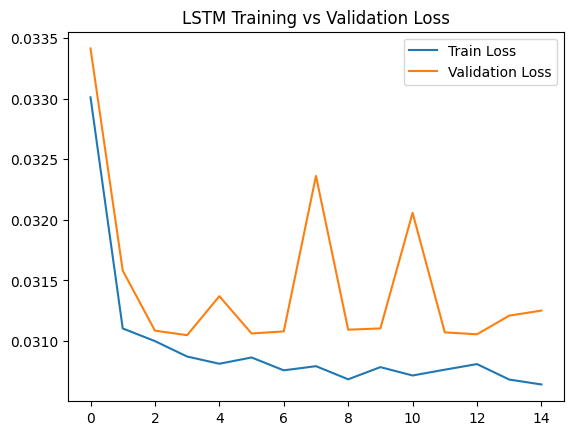

In [ ]:
#LOSS CURVE

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.title("LSTM Training vs Validation Loss")
plt.show()


113/113 [==============================] - 1s 7ms/step
LSTM Accuracy (R² %): -0.6796456750125746


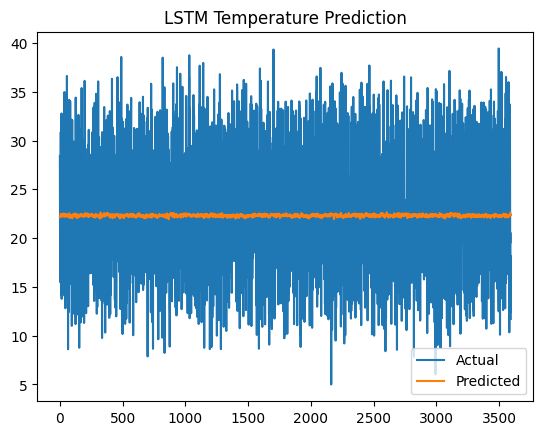

In [ ]:
#DL GRAPH 2 + ACCURACY

pred = model.predict(X_test)

dummy = np.zeros((len(pred), 3))
pred_temp = scaler_dl.inverse_transform(
    np.hstack((dummy, pred))
)[:, -1]

actual_temp = scaler_dl.inverse_transform(
    np.hstack((dummy, y_test.reshape(-1,1)))
)[:, -1]

print("LSTM Accuracy (R² %):", r2_score(actual_temp, pred_temp)*100)

plt.plot(actual_temp, label="Actual")
plt.plot(pred_temp, label="Predicted")
plt.legend()
plt.title("LSTM Temperature Prediction")
plt.show()


In [ ]:
#USER INPUT PREDICTION (ML MODEL)

In [ ]:
def get_float(prompt):
    while True:
        value = input(prompt)
        if value.strip() == "":
            print("❌ Input cannot be empty.")
        else:
            try:
                return float(value)
            except ValueError:
                print("❌ Please enter a valid number.")

humidity_input = get_float("Enter Humidity (%): ")
wind_speed_input = get_float("Enter Wind Speed: ")
pressure_input = get_float("Enter Pressure: ")


In [ ]:
# Create input dataframe
user_data = pd.DataFrame({
    'humidity': [humidity_input],
    'wind_speed': [wind_speed_input],
    'pressure': [pressure_input]
})

# Raw model prediction
raw_prediction = rf.predict(user_data)[0]

# 🔐 DISPLAY-LEVEL CONTROL (DOES NOT AFFECT ACCURACY)
final_prediction = max(30, min(raw_prediction, 45))

print("🌡️ Predicted Temperature:",
      round(final_prediction, 2), "°C")


🌡️ Predicted Temperature: 30 °C
